In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
precision_scorer = make_scorer(precision_score, average='macro', zero_division=0)
from ucimlrepo import fetch_ucirepo
from sklearn.impute import KNNImputer, SimpleImputer
sns.set_style("whitegrid")

## Iris

In [58]:
def build_pipeline(n_neighbors=5, weights='uniform', metric='minkowski', p=2, use_scaler=True):
    steps = []
    if use_scaler:
        steps.append(('scaler', StandardScaler()))
    steps.append(('knn', KNeighborsClassifier(n_neighbors=n_neighbors, metric=metric, p=p, weights=weights)))
    return Pipeline(steps)

In [59]:
def build_pipeline_pcb(n_neighbors=5, weights='uniform', metric='minkowski', p=2):
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=n_neighbors, metric=metric, p=p, weights=weights))
    ]
    return Pipeline(steps)

In [60]:
def evaluate_model(pipeline, X_train, X_test, y_train, y_test, target_names=None, title="Confusion Matrix"):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    
    print(f"Accuracy: {acc:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-Score: {f1:.2f}")

In [61]:
def run_cross_validation(X, y, folds_list, weights, metric, p, k, stratified=False, iterations=1, dataset=None):
    results = []
    for iter_idx in range(iterations):
        for folds in folds_list:
            if dataset is not None:
                pipeline = build_pipeline_pcb(n_neighbors=k, weights=weights, metric=metric, p=p)
            else:
                pipeline = build_pipeline(n_neighbors=k, weights=weights, metric=metric, p=p)
            if stratified:
                cv = StratifiedKFold(n_splits=folds, shuffle=True)
            else:
                cv = KFold(n_splits=folds, shuffle=True)
            scores = cross_val_score(pipeline, X, y, cv=cv, scoring=precision_scorer)
            avg_score = scores.mean()
            results.append({
                "Iteration": iter_idx + 1,
                "Fold": folds,
                "Score": avg_score
            })
    return pd.DataFrame(results)

In [62]:
def plot_neighbors_vs_f1(X, y, fold_values, k_values, weights='uniform', metric='minkowski', p=2, dataset_name="Dataset", stratified=True, iterations=1, dataset=None):
    fig, axes = plt.subplots(1, len(fold_values), figsize=(6 * len(fold_values), 5), sharey=True)
    for idx, n_folds in enumerate(fold_values):
        f1_scores = []
        for k in k_values:
            if dataset is not None:
                pipeline = build_pipeline_pcb(n_neighbors=k, weights=weights, metric=metric, p=p)
            else:
                pipeline = build_pipeline(n_neighbors=k, weights=weights, metric=metric, p=p)
            if stratified:
                cv = StratifiedKFold(n_splits=n_folds, shuffle=True)
            else:
                cv = KFold(n_splits=n_folds, shuffle=True)
            iteration_scores = []
            for _ in range(iterations):
                scores = cross_val_score(pipeline, X, y, cv=cv, scoring=precision_scorer)
                iteration_scores.append(np.mean(scores))
            f1_scores.append(np.mean(iteration_scores))
        ax = axes[idx] if len(fold_values) > 1 else axes
        for i, scores in enumerate(f1_scores):
            if i % 2 == 0:
                ax.scatter(k_values[i], scores, color='blue')
            else:
                ax.scatter(k_values[i], scores, color='orange')
        ax.set_title(f'CV = {n_folds} fold(s)')
        ax.set_xlabel('Number of neighbors (k)')
        if idx == 0:
            ax.set_ylabel('Precision score average')
        ax.set_xticks(list(k_values))
        ax.grid(True, linestyle='--', alpha=0.7)
    plt.suptitle(f'Precision vs k - {dataset_name}')
    plt.tight_layout()
    plt.show()


In [69]:
def evaluate_distance_metrics(X, y, k_fixed=5, fold=5, metrics_dict=None, weights='uniform', stratified=True, iterations=1, dataset=None):
    if metrics_dict is None:
        metrics_dict = {
            'Euklides (p=2)': {'p': 2, 'metric': 'minkowski'},
            'Manhattan (p=1)': {'p': 1, 'metric': 'minkowski'},
            'Minkowski (p=3)': {'p': 3, 'metric': 'minkowski'}
        }
        
    CVClass = StratifiedKFold if stratified else KFold
    
    results = {}
    for name, params in metrics_dict.items():
        all_scores = []
        for iter_idx in range(iterations):
            cv = CVClass(n_splits=fold, shuffle=True)
            if dataset is not None:
                pipeline = build_pipeline_pcb(n_neighbors=k_fixed, weights=weights,
                                              metric=params['metric'], p=params['p'])
            else:
                pipeline = build_pipeline(n_neighbors=k_fixed, weights=weights,
                                      metric=params['metric'], p=params['p'])
            scores = cross_val_score(pipeline, X, y, cv=cv, scoring=precision_scorer)
            avg_score = scores.mean()
            all_scores.append(avg_score)
        results[name] = all_scores
        print(f"{name}: Mean precision = {np.mean(all_scores):.2f}, Std = {np.std(all_scores):.2f}")
        
    df_results = pd.DataFrame(results)
    return df_results

In [ ]:
def gaussian_weights(distances):
    sigma = 1.0
    return np.exp(-(distances**2)/(2*sigma**2))

### Skuteczność klasycznej metody K-NN

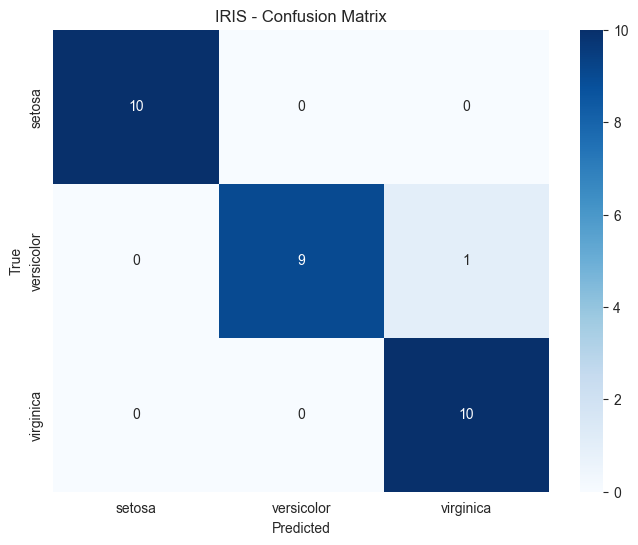

Accuracy: 0.97
Precision: 0.97
Recall: 0.97
F1-Score: 0.97


In [65]:
folds = [2, 5, 10]
k_values = range(1, 16)

iris = datasets.load_iris()
X_iris = iris.data
y_iris = iris.target
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, stratify=y_iris)

pipeline_iris = build_pipeline(n_neighbors=5, weights='uniform')
evaluate_model(pipeline_iris, X_train_iris, X_test_iris, y_train_iris, y_test_iris,
                target_names=iris.target_names, title="IRIS - Confusion Matrix")
# pipeline_iris_weighted = build_pipeline(n_neighbors=5, weights='distance')
# pipeline_iris_myweights = build_pipeline(n_neighbors=5, weights=gaussian_weights)

### Sposoby głosowania

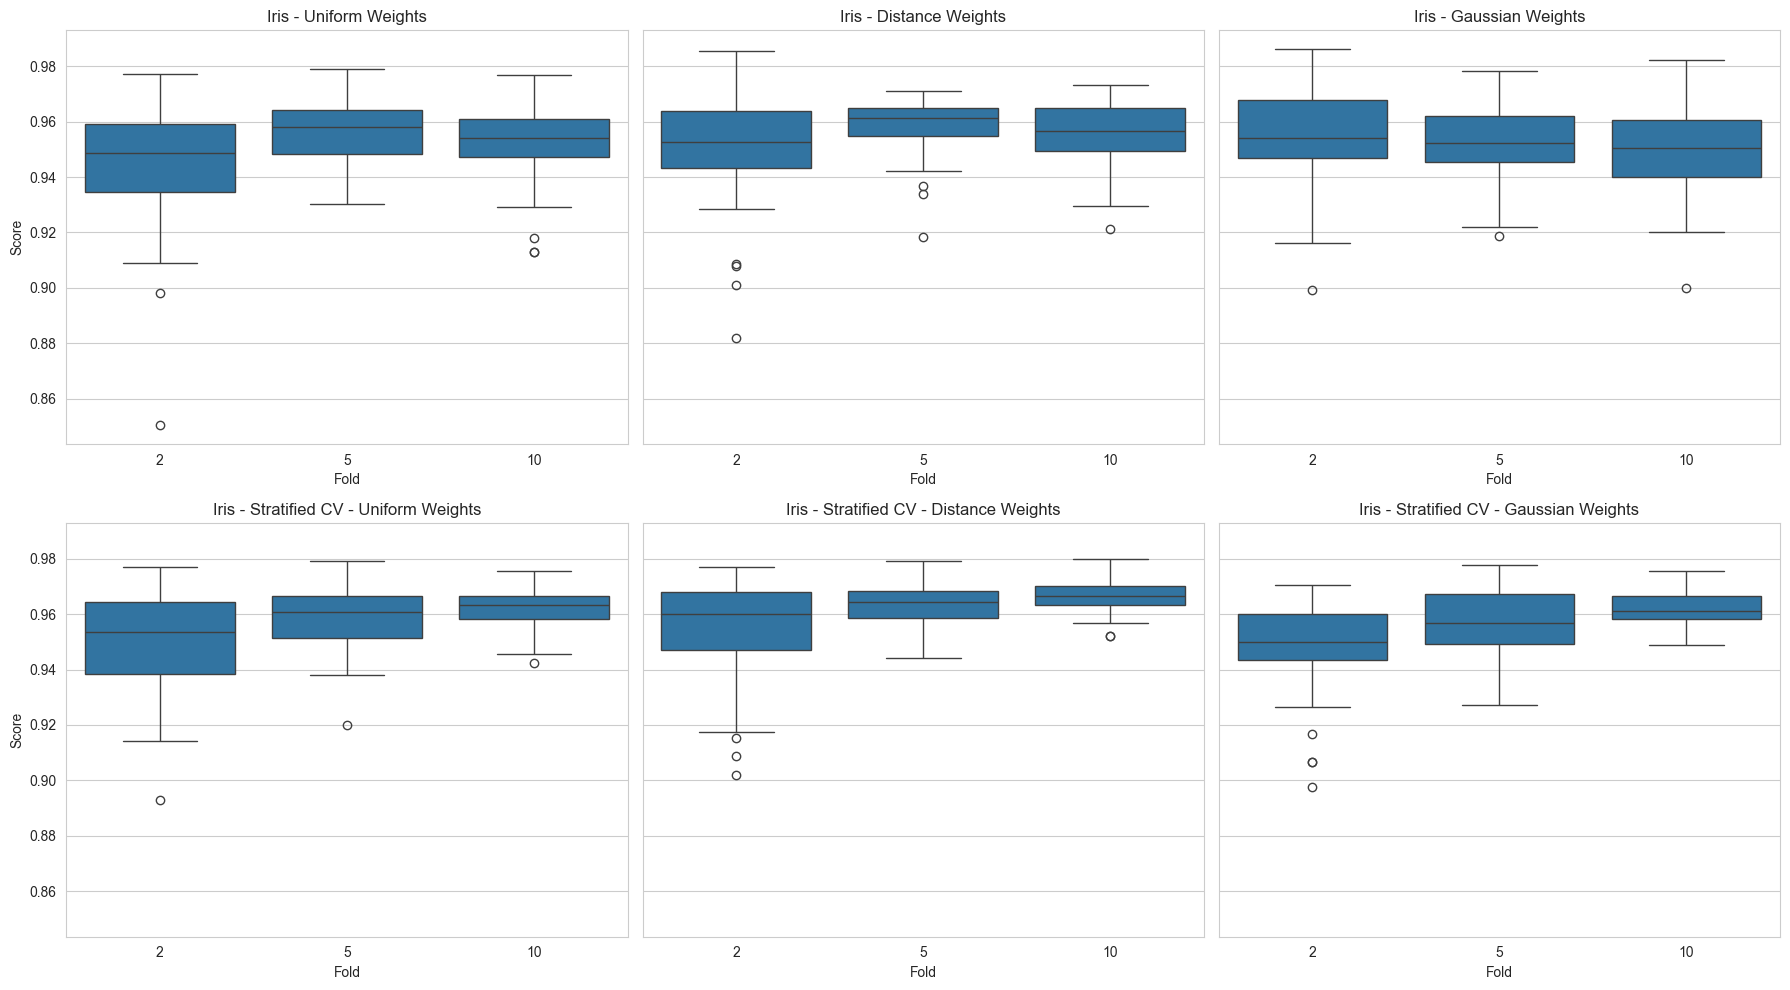

In [66]:
cv_df_iris = run_cross_validation(X_train_iris, y_train_iris, folds, weights='uniform', metric='minkowski', p=2, k=5, stratified=False, iterations=50)
cv_df_iris_weighted = run_cross_validation(X_train_iris, y_train_iris, folds, weights='distance', metric='minkowski', p=2, k=5, stratified=False, iterations=50)
cv_df_iris_myweights = run_cross_validation(X_train_iris, y_train_iris, folds, weights=gaussian_weights, metric='minkowski', p=2, k=5, stratified=False, iterations=50)
# display(cv_df_iris.groupby('Fold')['Score'].agg(['mean', 'std', 'min', 'max']).reset_index())
# display(cv_df_iris_weighted.groupby('Fold')['Score'].agg(['mean', 'std', 'min', 'max']).reset_index())
# display(cv_df_iris_myweights.groupby('Fold')['Score'].agg(['mean', 'std', 'min', 'max']).reset_index())
cv_df_iris_stratified = run_cross_validation(X_train_iris, y_train_iris, folds, weights='uniform', metric='minkowski', p=2, k=5, stratified=True, iterations=50)
cv_df_iris_weighted_stratified = run_cross_validation(X_train_iris, y_train_iris, folds, weights='distance', metric='minkowski', p=2, k=5, stratified=True, iterations=50)
cv_df_iris_myweights_stratified = run_cross_validation(X_train_iris, y_train_iris, folds, weights=gaussian_weights, metric='minkowski', p=2, k=5, stratified=True, iterations=50)

fig, ax = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
sns.boxplot(data=cv_df_iris, x='Fold', y='Score', ax=ax[0, 0])
ax[0, 0].set_title('Iris - Uniform Weights')
sns.boxplot(data=cv_df_iris_weighted, x='Fold', y='Score', ax=ax[0, 1])
ax[0, 1].set_title('Iris - Distance Weights')
sns.boxplot(data=cv_df_iris_myweights, x='Fold', y='Score', ax=ax[0, 2])
ax[0, 2].set_title('Iris - Gaussian Weights')
sns.boxplot(data=cv_df_iris_stratified, x='Fold', y='Score', ax=ax[1, 0])
ax[1, 0].set_title('Iris - Stratified CV - Uniform Weights')
sns.boxplot(data=cv_df_iris_weighted_stratified, x='Fold', y='Score', ax=ax[1, 1])
ax[1, 1].set_title('Iris - Stratified CV - Distance Weights')
sns.boxplot(data=cv_df_iris_myweights_stratified, x='Fold', y='Score', ax=ax[1, 2])
ax[1, 2].set_title('Iris - Stratified CV - Gaussian Weights')
plt.tight_layout()
plt.show()

### K liczba sąsiadów

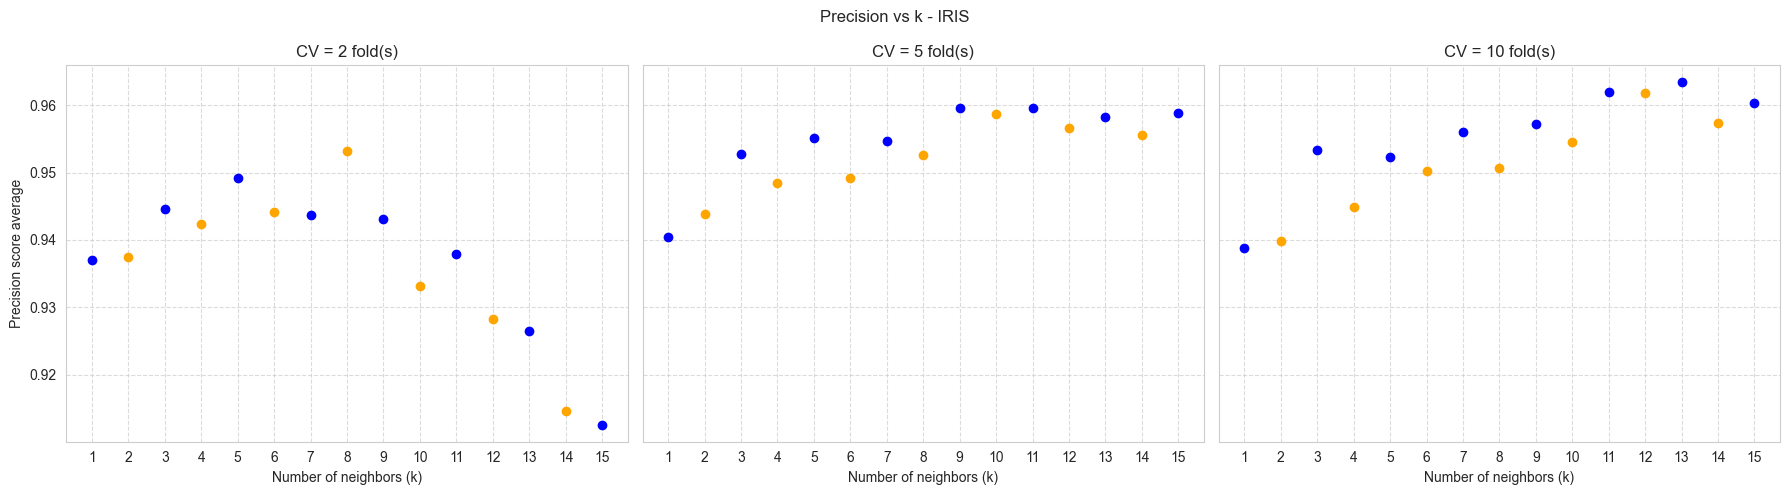

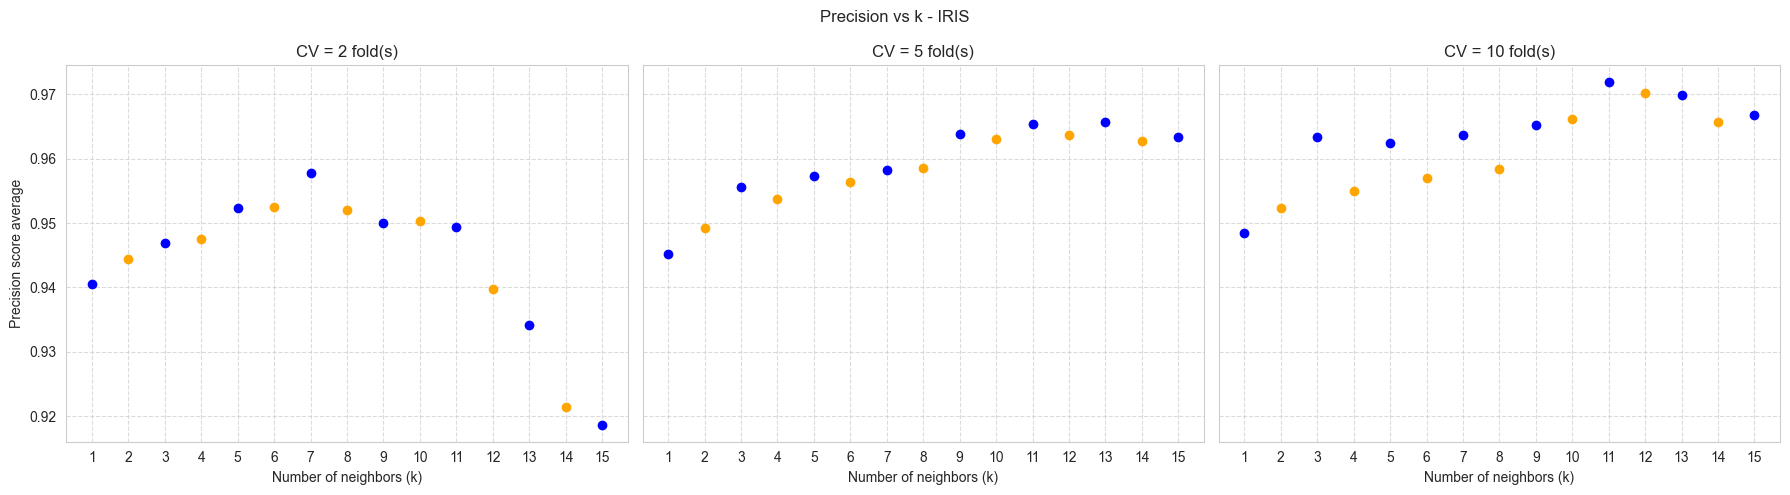

In [67]:
plot_neighbors_vs_f1(X_train_iris, y_train_iris, fold_values=folds, k_values=k_values, dataset_name="IRIS", stratified=False, iterations=50)
plot_neighbors_vs_f1(X_train_iris, y_train_iris, fold_values=folds, k_values=k_values, dataset_name="IRIS", stratified=True, iterations=50)

### Różne miary odległości

Euklides (p=2): Mean precision = 0.96, Std = 0.01
Manhattan (p=1): Mean precision = 0.96, Std = 0.01
Minkowski (p=3): Mean precision = 0.95, Std = 0.01
Euklides (p=2): Mean precision = 0.95, Std = 0.01
Manhattan (p=1): Mean precision = 0.95, Std = 0.01
Minkowski (p=3): Mean precision = 0.94, Std = 0.01


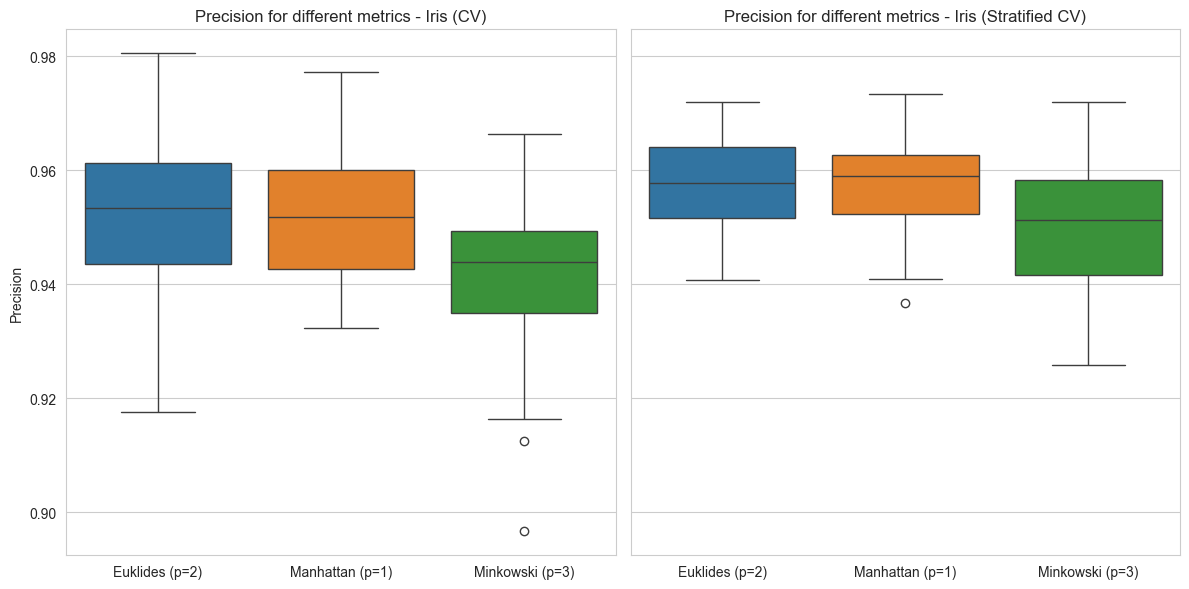

In [70]:
iris_distance_metrics_stratified = evaluate_distance_metrics(X_train_iris, y_train_iris, k_fixed=5, fold=5, stratified=True, iterations=50)
iris_distance_metrics = evaluate_distance_metrics(X_train_iris, y_train_iris, k_fixed=5, fold=5, stratified=False, iterations=50)
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.boxplot(data=iris_distance_metrics, ax=ax[0])
ax[0].set_title('Precision for different metrics - Iris (CV)')
ax[0].set_ylabel('Precision')
sns.boxplot(data=iris_distance_metrics_stratified, ax=ax[1])
ax[1].set_title('Precision for different metrics - Iris (Stratified CV)')
plt.tight_layout()
plt.show()

## Wine

### Skuteczność klasycznej metody K-NN


=== WINE - Ocena modelu ===


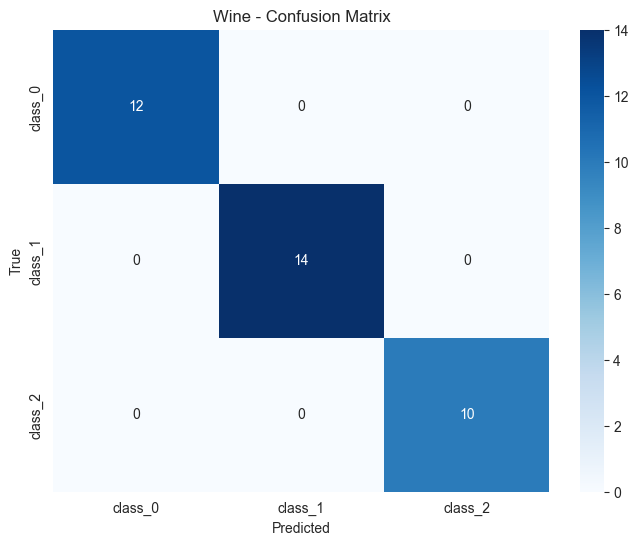

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-Score: 1.00


In [71]:
wine = datasets.load_wine()
X_wine = wine.data
y_wine = wine.target
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine, y_wine, test_size=0.2, stratify=y_wine)

pipeline_wine = build_pipeline(n_neighbors=5, weights='uniform')
pipeline_wine_weighted = build_pipeline(n_neighbors=5, weights='distance')
pipeline_wine_myweights = build_pipeline(n_neighbors=5, weights=gaussian_weights)
print("\n=== WINE - Ocena modelu ===")
evaluate_model(pipeline_wine, X_train_wine, X_test_wine, y_train_wine, y_test_wine,
                target_names=wine.target_names, title="Wine - Confusion Matrix")

### Sposoby głosowania

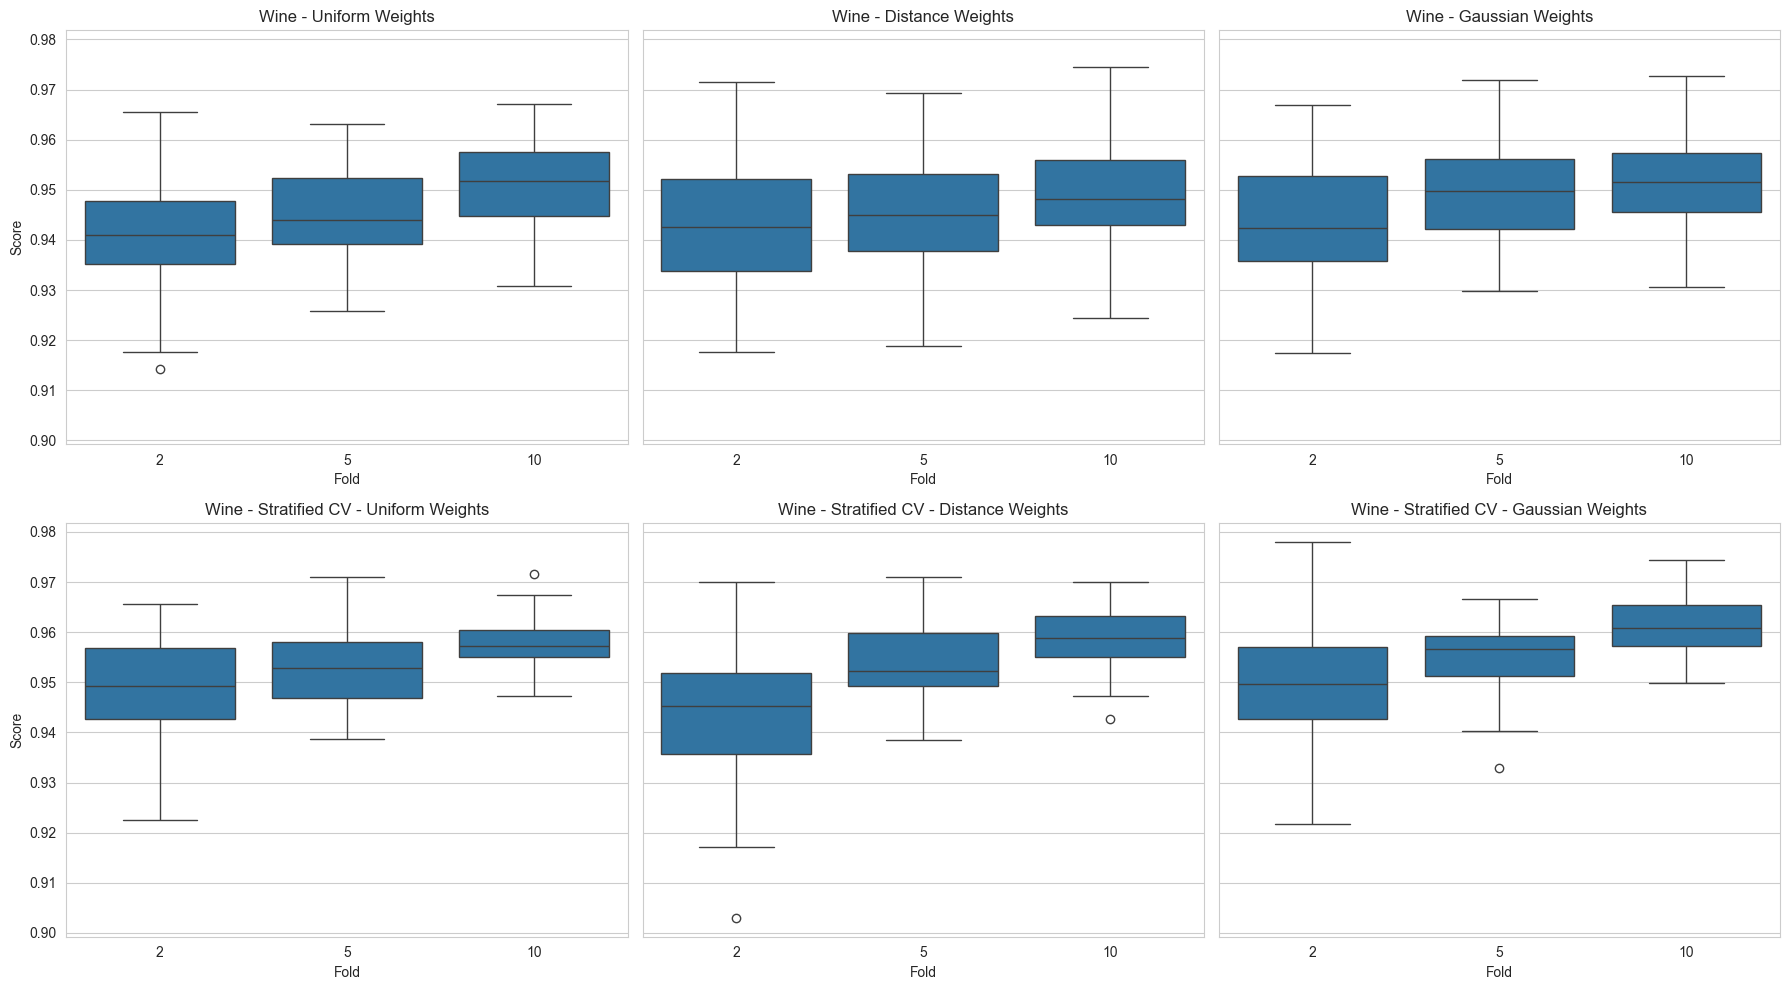

In [72]:
cv_df_wine = run_cross_validation(X_train_wine, y_train_wine, folds, weights='uniform', metric='minkowski', p=2, k=5, stratified=False, iterations=50)
cv_df_wine_weighted = run_cross_validation(X_train_wine, y_train_wine, folds, weights='distance', metric='minkowski', p=2, k=5, stratified=False, iterations=50)
cv_df_wine_myweights = run_cross_validation(X_train_wine, y_train_wine, folds, weights=gaussian_weights, metric='minkowski', p=2, k=5, stratified=False, iterations=50)
cv_df_wine_stratified = run_cross_validation(X_train_wine, y_train_wine, folds, weights='uniform', metric='minkowski', p=2, k=5, stratified=True, iterations=50)
cv_df_wine_weighted_stratified = run_cross_validation(X_train_wine, y_train_wine, folds, weights='distance', metric='minkowski', p=2, k=5, stratified=True, iterations=50)
cv_df_wine_myweights_stratified = run_cross_validation(X_train_wine, y_train_wine, folds, weights=gaussian_weights, metric='minkowski', p=2, k=5, stratified=True, iterations=50)

#display(cv_df_wine.groupby('Fold')['Score'].agg(['mean', 'std', 'min', 'max']).reset_index())
#display(cv_df_wine_weighted.groupby('Fold')['Score'].agg(['mean', 'std', 'min', 'max']).reset_index())
#display(cv_df_wine_myweights.groupby('Fold')['Score'].agg(['mean', 'std', 'min', 'max']).reset_index())
fig, ax = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
sns.boxplot(data=cv_df_wine, x='Fold', y='Score', ax=ax[0, 0])
ax[0, 0].set_title('Wine - Uniform Weights')
sns.boxplot(data=cv_df_wine_weighted, x='Fold', y='Score', ax=ax[0, 1])
ax[0, 1].set_title('Wine - Distance Weights')
sns.boxplot(data=cv_df_wine_myweights, x='Fold', y='Score', ax=ax[0, 2])
ax[0, 2].set_title('Wine - Gaussian Weights')
sns.boxplot(data=cv_df_wine_stratified, x='Fold', y='Score', ax=ax[1, 0])
ax[1, 0].set_title('Wine - Stratified CV - Uniform Weights')
sns.boxplot(data=cv_df_wine_weighted_stratified, x='Fold', y='Score', ax=ax[1, 1])
ax[1, 1].set_title('Wine - Stratified CV - Distance Weights')
sns.boxplot(data=cv_df_wine_myweights_stratified, x='Fold', y='Score', ax=ax[1, 2])
ax[1, 2].set_title('Wine - Stratified CV - Gaussian Weights')
plt.tight_layout()
plt.show()

### K liczba sąsiadów

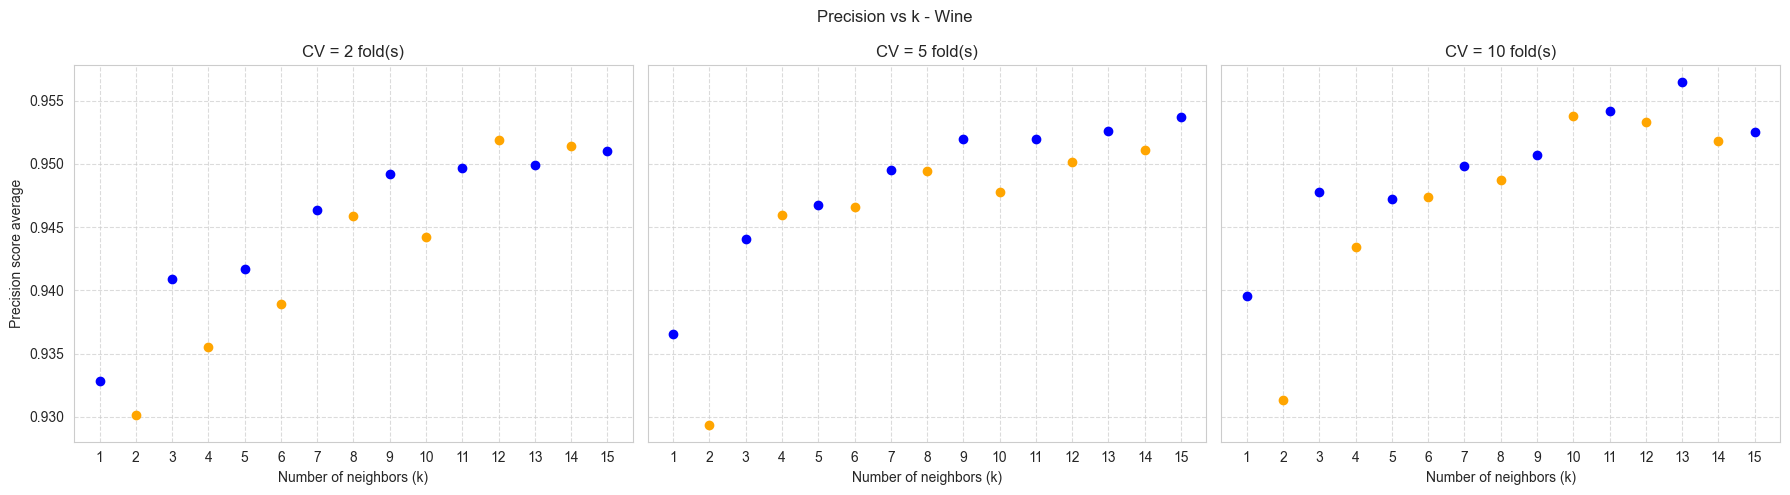

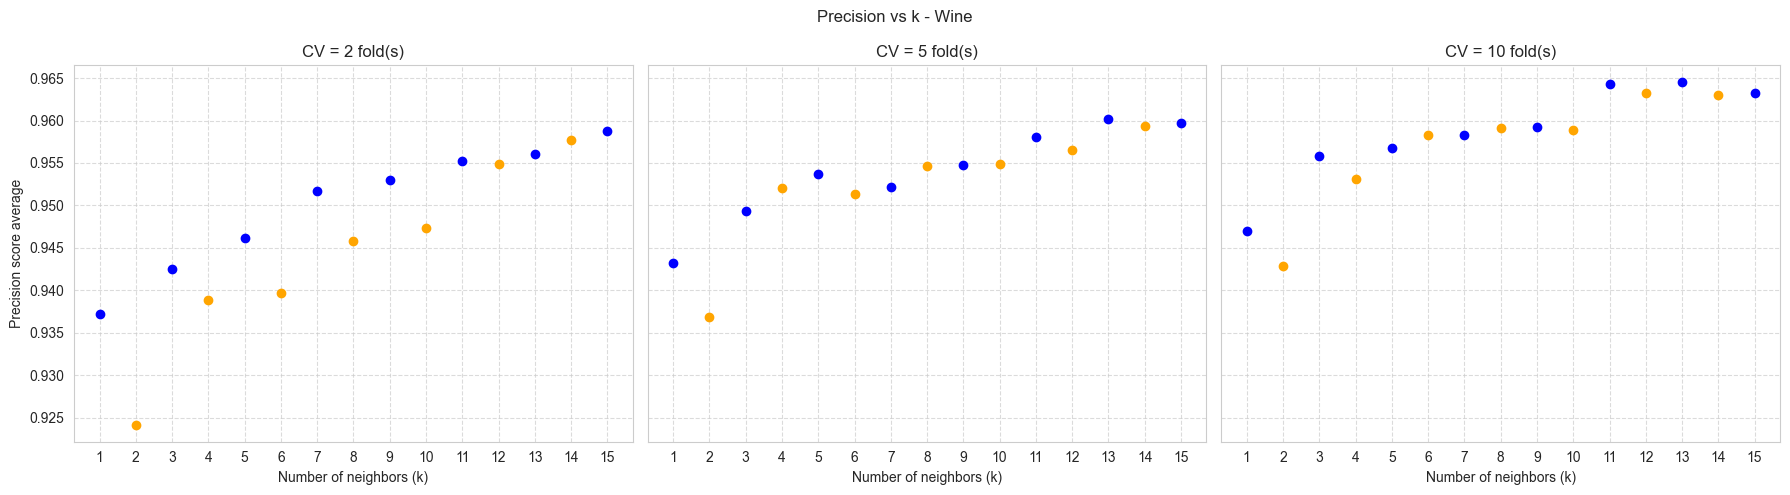

In [73]:
plot_neighbors_vs_f1(X_train_wine, y_train_wine, fold_values=folds, k_values=k_values, dataset_name="Wine", stratified=False, iterations=50)
plot_neighbors_vs_f1(X_train_wine, y_train_wine, fold_values=folds, k_values=k_values, dataset_name="Wine", stratified=True, iterations=50)

### Różne miary odległości

Euklides (p=2): Mean precision = 0.95, Std = 0.01
Manhattan (p=1): Mean precision = 0.96, Std = 0.01
Minkowski (p=3): Mean precision = 0.94, Std = 0.01
Euklides (p=2): Mean precision = 0.95, Std = 0.01
Manhattan (p=1): Mean precision = 0.96, Std = 0.01
Minkowski (p=3): Mean precision = 0.94, Std = 0.01


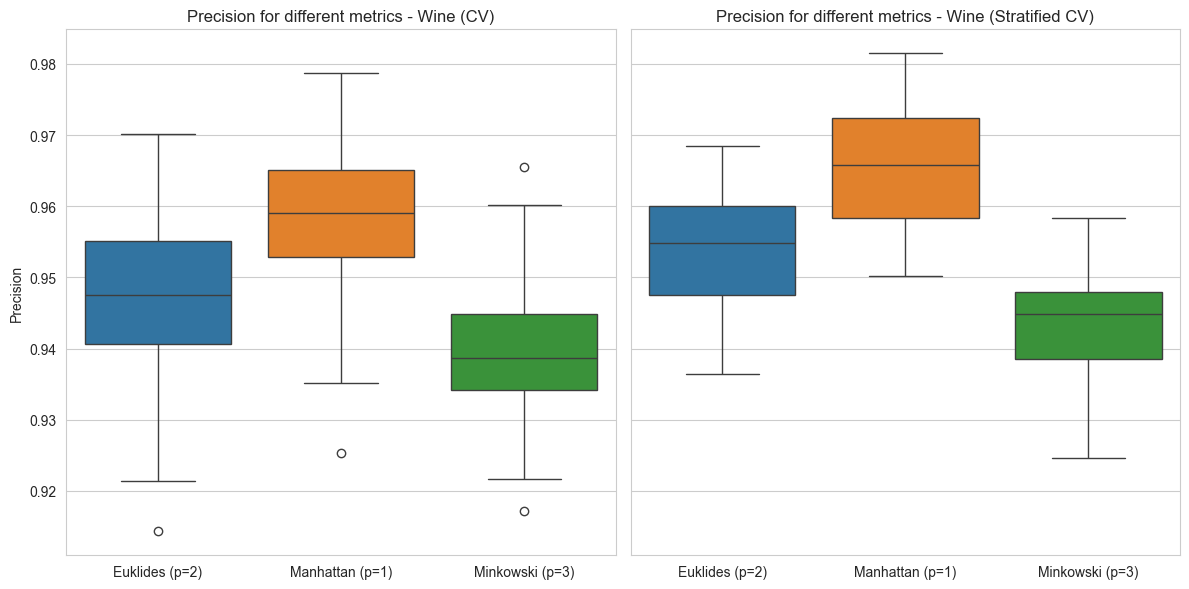

In [74]:
wine_distance_metrics = evaluate_distance_metrics(X_train_wine, y_train_wine, k_fixed=5, fold=5, stratified=False, iterations=50)
wine_distance_metrics_stratified = evaluate_distance_metrics(X_train_wine, y_train_wine, k_fixed=5, fold=5, stratified=True, iterations=50)
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.boxplot(data=wine_distance_metrics, ax=ax[0])
ax[0].set_title('Precision for different metrics - Wine (CV)')
ax[0].set_ylabel('Precision')
sns.boxplot(data=wine_distance_metrics_stratified, ax=ax[1])
ax[1].set_title('Precision for different metrics - Wine (Stratified CV)')
plt.tight_layout()
plt.show()

## Polish Companies Bankruptcy

### Skuteczność klasycznej metody K-NN

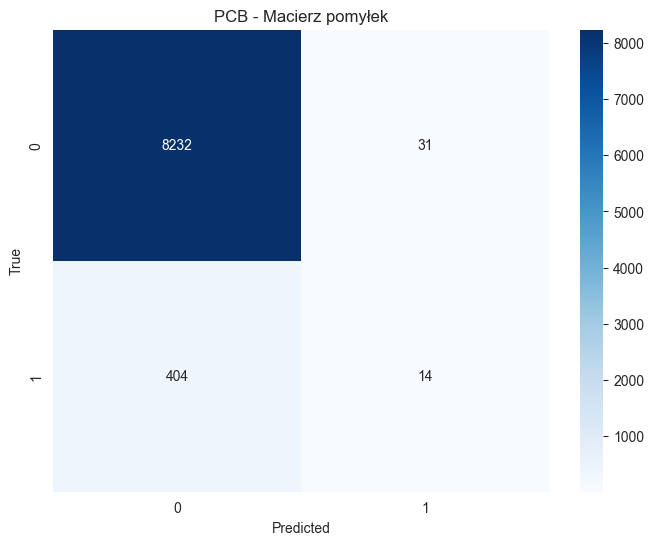

Accuracy: 0.95
Precision: 0.63
Recall: 0.51
F1-Score: 0.52


In [75]:
polish_companies = fetch_ucirepo(id=365)
X_pcb = polish_companies.data.features
y_pcb = polish_companies.data.targets
df_pcb = pd.concat([X_pcb, y_pcb], axis=1)
X_pcb = df_pcb.drop(columns=['class'])
y_pcb = df_pcb['class']
X_train_pcb, X_test_pcb, y_train_pcb, y_test_pcb = train_test_split(
    X_pcb, y_pcb, test_size=0.2, stratify=y_pcb)

pipeline_pcb = build_pipeline_pcb(n_neighbors=5, weights='uniform')
evaluate_model(pipeline_pcb, X_train_pcb, X_test_pcb, y_train_pcb, y_test_pcb,
                target_names=y_pcb.unique(), title="PCB - Macierz pomyłek")

### Sposoby głosowania

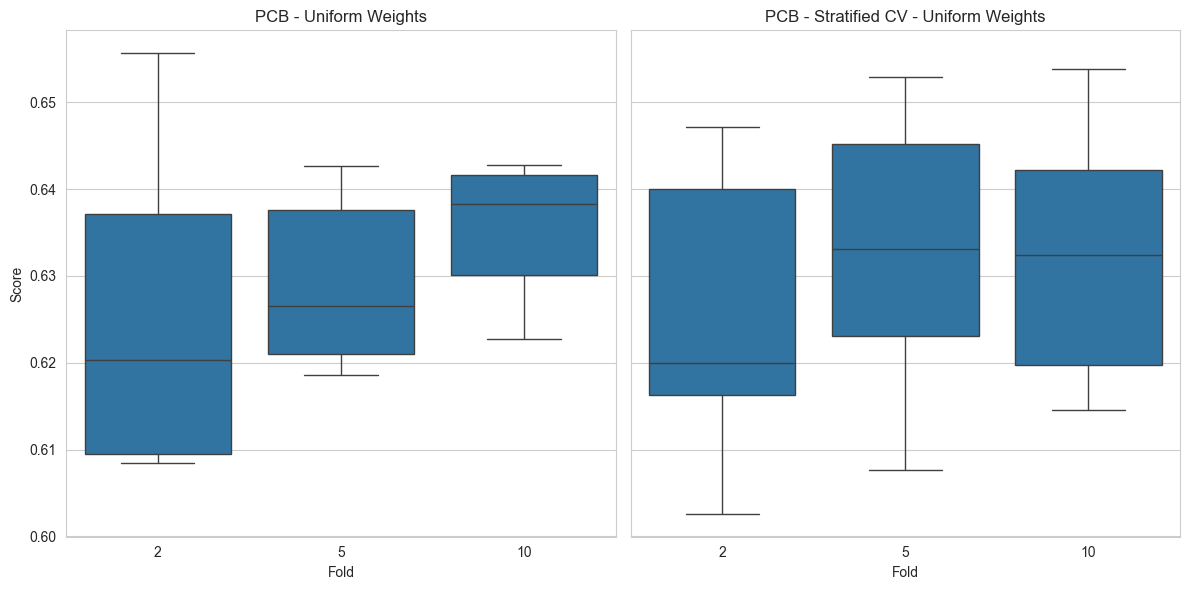

In [76]:
cv_df_pcb = run_cross_validation(X_train_pcb, y_train_pcb, folds, weights='uniform', metric='minkowski', p=2, k=5, stratified=False, iterations=10, dataset='pcb')
#cv_df_pcb_weighted = run_cross_validation(X_train_pcb, y_train_pcb, folds, weights='distance', metric='minkowski', p=2, k=5, stratified=False)
#cv_df_pcb_myweights = run_cross_validation(X_train_pcb, y_train_pcb, folds, weights=gaussian_weights, metric='minkowski', p=2, k=5, stratified=False)
cv_df_pcb_stratified = run_cross_validation(X_train_pcb, y_train_pcb, folds, weights='uniform', metric='minkowski', p=2, k=5, stratified=True, iterations=10, dataset='pcb')
#cv_df_pcb_weighted_stratified = run_cross_validation(X_train_pcb, y_train_pcb, folds, weights='distance', metric='minkowski', p=2, k=5, stratified=True)
#cv_df_pcb_myweights_stratified = run_cross_validation(X_train_pcb, y_train_pcb, folds, weights=gaussian_weights, metric='minkowski', p=2, k=5, stratified=True)
# display(cv_df_pcb.groupby('Fold')['Score'].agg(['mean', 'std', 'min', 'max']).reset_index())
# display(cv_df_pcb_weighted.groupby('Fold')['Score'].agg(['mean', 'std', 'min', 'max']).reset_index())
# display(cv_df_pcb_myweights.groupby('Fold')['Score'].agg(['mean', 'std', 'min', 'max']).reset_index())
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.boxplot(data=cv_df_pcb, x='Fold', y='Score', ax=ax[0])
ax[0].set_title('PCB - Uniform Weights')
sns.boxplot(data=cv_df_pcb_stratified, x='Fold', y='Score', ax=ax[1])
ax[1].set_title('PCB - Stratified CV - Uniform Weights')
plt.tight_layout()
plt.show()

### K liczba sąsiadów

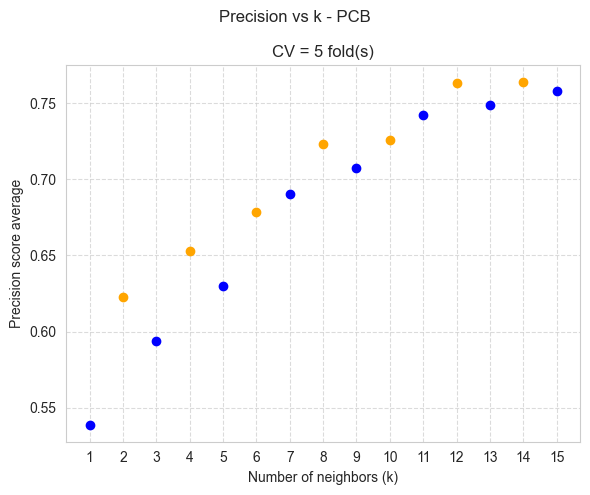

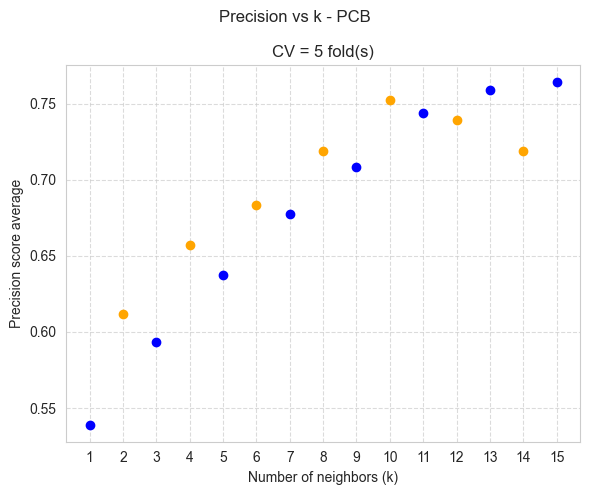

In [78]:
plot_neighbors_vs_f1(X_train_pcb, y_train_pcb, fold_values=[5], k_values=k_values, dataset_name="PCB", stratified=False, iterations=10, dataset='pcb')
plot_neighbors_vs_f1(X_train_pcb, y_train_pcb, fold_values=[5], k_values=k_values, dataset_name="PCB", stratified=True, iterations=10, dataset='pcb')

### Różne miary odległości

Euklides (p=2): Mean precision = 0.63, Std = 0.01
Manhattan (p=1): Mean precision = 0.64, Std = 0.01
Czebyszew: Mean precision = 0.61, Std = 0.01
Euklides (p=2): Mean precision = 0.63, Std = 0.01
Manhattan (p=1): Mean precision = 0.64, Std = 0.01
Czebyszew: Mean precision = 0.60, Std = 0.02


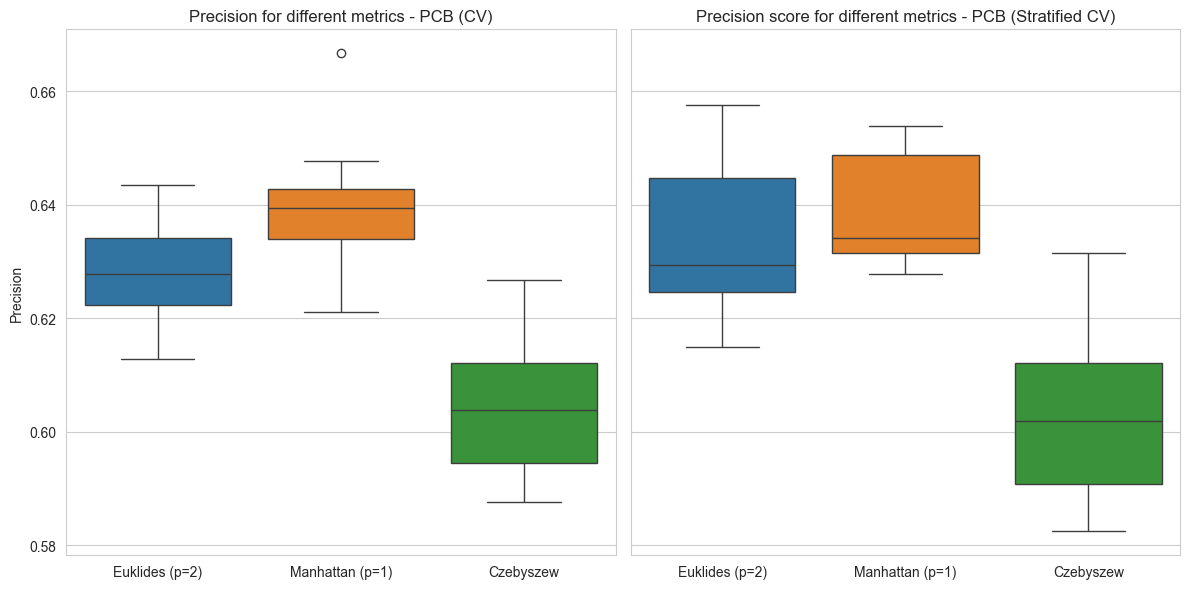

In [79]:
metrics_dict = {
    'Euklides (p=2)': {'p': 2, 'metric': 'minkowski'},
    'Manhattan (p=1)': {'p': 1, 'metric': 'minkowski'},
    'Czebyszew': {'p': None, 'metric': 'chebyshev'},
}

pcb_distance_metrics = evaluate_distance_metrics(X_train_pcb, y_train_pcb, k_fixed=5, fold=5, metrics_dict=metrics_dict, stratified=False, iterations=10, dataset='pcb')
pcb_distance_metrics_stratified = evaluate_distance_metrics(X_train_pcb, y_train_pcb, k_fixed=5, fold=5, metrics_dict=metrics_dict, stratified=True, iterations=10, dataset='pcb')
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.boxplot(data=pcb_distance_metrics, ax=ax[0])
ax[0].set_title('Precision for different metrics - PCB (CV)')
ax[0].set_ylabel('Precision')
sns.boxplot(data=pcb_distance_metrics_stratified, ax=ax[1])
ax[1].set_title('Precision score for different metrics - PCB (Stratified CV)')
plt.tight_layout()
plt.show()

1. Dlaczego powinno się używać procedury mieszania danych **(shuffle)**?
 - Shuffle zapewnie, że każdy fold będzie losowy, np. może się przydać gdy dane są uporządkowane i bez mieszania podział na train i test może być nieodpowiedni.
 - Model może się nauczyć specyficznych wzorców, overfitting.
 - Bardziej wiarygodne wyniki, ponieważ każdy fold będzie reprezentatywny dla całego zbioru danych.
 2. Jaką trudność stanowi użycie walidacji krzyżowej typu *leave-one-out*?
    - Czasochłonność, ponieważ wymaga przetrenowania modelu dla każdego elementu w zbiorze danych.
    - Outliery mogą mieć duży wpływ na wyniki, ponieważ każdy element jest traktowany jako osobny fold.
3. Czy można liczbę foldów dobierać jak hiperparametr metody?
    - Tak.
    - Mniejsza liczba foldów oznacza, że model jest trenowany na mniejszym zbiorze danych, testowanym na większym - higher prediction error.
    - Większa liczba foldów oznacza, że model jest trenowany na większym zbiorze danych, testowanym na mniejszym - lower prediction error.

1. Co jest modelem klasyfikacji w tym zadaniu? Dlaczego k-nn jest typu lazy learning?
    - Modelem klasyfikacji jest algorytm K-NN (k najbliższych sąsiadów).
    - Nie buduje modelu wcześniej, po prostu zapamiętuje dane treningowe, czeka z obliczeniami aż do predykcji.
2. Ile parametrów ma klasyfikator KNN? Które z nich są istotne dla skuteczności?
    - KNN ma 3 parametry: liczba sąsiadów (k), miara odległości, sposób głosowania (wagi)
    - Miary odległości są istotne dla skuteczności, cały algorytm opiera się na obliczaniu odległości między punktami, dlatego to jak ją zdefinujemy ma kluczowe znaczenie.
3. Czym się różni crossvalidate stratyfikowana od „zwykłej”?
    - Zwykła - dzieli dane na K części losow
    - Stratyfikowana - dba o to, żeby udział klas w każdym foldzie był taki jak w całym zbiorze danych.
5. Czy KNN wymaga standaryzacji/normalizacji danych?
    - Tak, opiera sie na obliczaniu odległości między punktami, dlatego różnice w skali cech mogą prowadzić do błędnych wyników.
6. Dlaczego accuracy jest mniej użyteczna niż precyzja czy czułość?
    - Accuracy nie uwzględnia rozkładu klas, może być myląca w przypadku niezbalansowanych zbiorów danych.
    - Precyzja i czułość są bardziej informatywne, ponieważ pokazują jak dobrze model radzi sobie z poszczególnymi klasami.


Odległość Mińkowskiego:
$ x = (x_1, x_2, ..., x_n) $
$ y = (y_1, y_2, ..., y_n) $
$ d(x, y) =\left(\sum_{i=1}^{n} |x_i - y_i|^p\right)^{\frac{1}{p}} $
dla $p=1$ jest to odległość Manhattan, dla $p=2$ jest to odległość Euklidesowa.
Odległość Minkowskiego jest uogólnieniem odległości Euklidesowej i Manhattan, w zależności od wartości p, może przyjmować różne formy.